✅ Dataset loaded successfully!
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  
✅ Model training co

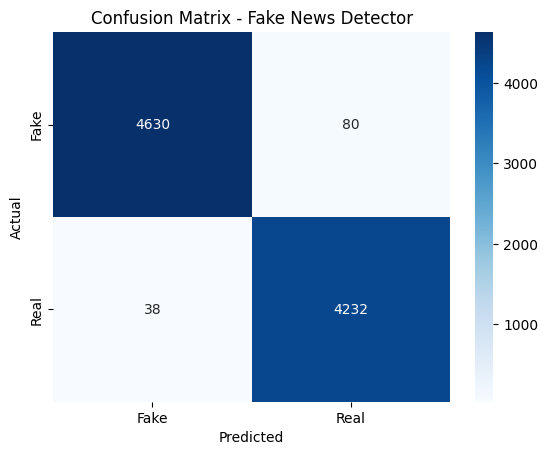

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a02dc55d3770f5271b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ==============================================
# 📘 Step 1: Import Required Libraries
# ==============================================
import pandas as pd
import zipfile
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import gradio as gr

# ==============================================
# 📦 Step 2: Extract and Load Dataset
# ==============================================
zip_path = '/content/archive.zip'  # <-- your uploaded file

# Extract files
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

# Check extracted files
os.listdir('/content/dataset')

# Usually the dataset has two files: 'Fake.csv' and 'True.csv'
fake_path = '/content/dataset/Fake.csv'
true_path = '/content/dataset/True.csv'

# Load both
fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

# Add labels
fake_df['label'] = 0   # Fake = 0
true_df['label'] = 1   # Real = 1

# Combine and shuffle
df = pd.concat([fake_df, true_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
print("✅ Dataset loaded successfully!")
print(df.head())

# ==============================================
# 🧹 Step 3: Clean and Preprocess Text
# ==============================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)  # remove non-letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned'] = df['text'].apply(clean_text)

# ==============================================
# 📊 Step 4: Train-Test Split
# ==============================================
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned'], df['label'], test_size=0.2, random_state=42
)

# ==============================================
# ✍️ Step 5: Convert Text to TF-IDF Features
# ==============================================
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ==============================================
# 🤖 Step 6: Train Model
# ==============================================
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)
print("✅ Model training completed!")

# ==============================================
# 🧩 Step 7: Evaluate Model
# ==============================================
y_pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {acc*100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Fake News Detector")
plt.show()

# ==============================================
# 🚀 Step 8: Interactive Gradio App
# ==============================================
def predict_news(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)[0]
    prob = model.predict_proba(vector)[0][prediction]
    if prediction == 1:
        return f"✅ This news seems REAL. (Confidence: {prob*100:.2f}%)"
    else:
        return f"🚫 This news seems FAKE. (Confidence: {prob*100:.2f}%)"

demo = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(label="Enter a News Headline or Article Text:"),
    outputs="text",
    title="📰 Fake News Detector",
    description="A machine learning model that detects whether a news article is real or fake using Logistic Regression and TF-IDF features."
)

demo.launch(share=True)